In [ ]:
import nltk
import polars as pl
from nltk.corpus import stopwords

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score

In [ ]:
df = pl.read_parquet("../data/dataset_small.parquet")

In [ ]:
corpus = df.with_columns(
    pl.col("content_clean")
    .str.to_lowercase()
    .str.replace_all(r"\b(" + "|".join(set(stopwords.words("english"))) + r")\b", "")
    .str.replace_all(r"\s+", " ")
    .str.strip_chars()
    .alias("harmonized_content")
)

# Klassenfilter als Kuchendiagram argurmentieren. Wir haben 5 Klassen mit insgesamt mehr als 50% gewählt!

corpus = (corpus
    .filter(pl.col("emotion").is_in(["neutral", "worry", "hapiness", "sadness", "love"]))
    .filter((pl.col("content_clean") == "").not_())
).select("tweet_id", "emotion", "content", "content_clean", "harmonized_content")

corpus

tweet_id,emotion,content,content_clean,harmonized_content
u32,str,str,str,str
1,"""sadness""","""Layin n bed with a headache u…","""layin n bed with a headache ug…","""layin n bed headache ughhhhwai…"
2,"""sadness""","""Funeral ceremony...gloomy frid…","""funeral ceremonygloomy friday""","""funeral ceremonygloomy friday"""
4,"""neutral""","""@dannycastillo We want to trad…","""we want to trade with someone …","""want trade someone houston tic…"
5,"""worry""","""Re-pinging @ghostridah14: why …","""repinging why didnt you go to …","""repinging didnt go prom bc bf …"
6,"""sadness""","""I should be sleep, but im not!…","""i should be sleep but im not t…","""sleep im thinking old friend w…"
…,…,…,…,…
39992,"""neutral""","""@jasimmo Ooo showing of your F…","""ooo showing of your french ski…","""ooo showing french skills lol …"
39993,"""neutral""","""@sendsome2me haha, yeah. Twitt…","""haha yeah twitter has many use…","""haha yeah twitter many uses kn…"
39996,"""love""","""Happy Mothers Day All my love""","""happy mothers day all my love""","""happy mothers day love"""


In [ ]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(corpus["harmonized_content"])
y = corpus["emotion"]

print(X)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 176592 stored elements and shape (26020, 25116)>
  Coords	Values
  (0, 11929)	1
  (0, 1897)	1
  (0, 9468)	1
  (0, 22927)	1
  (0, 3173)	1
  (1, 8177)	1
  (1, 3517)	1
  (1, 8038)	1
  (2, 23752)	1
  (2, 22360)	1
  (2, 20076)	1
  (2, 10059)	1
  (2, 21911)	1
  (2, 15135)	1
  (3, 17981)	1
  (3, 5688)	2
  (3, 8626)	1
  (3, 16767)	1
  (3, 1815)	1
  (3, 2083)	1
  (3, 12152)	1
  (3, 8062)	1
  (4, 23752)	1
  (4, 19777)	1
  (4, 10376)	1
  :	:
  (26017, 12520)	1
  (26017, 5245)	1
  (26017, 9343)	1
  (26017, 13899)	1
  (26018, 20076)	1
  (26018, 24940)	1
  (26018, 5245)	2
  (26018, 9343)	1
  (26018, 24405)	1
  (26018, 12881)	1
  (26018, 12401)	1
  (26018, 13723)	1
  (26018, 13899)	1
  (26018, 13731)	1
  (26019, 21889)	1
  (26019, 19606)	1
  (26019, 22384)	1
  (26019, 22144)	1
  (26019, 23549)	1
  (26019, 10970)	1
  (26019, 8456)	1
  (26019, 2940)	1
  (26019, 23326)	1
  (26019, 8265)	1
  (26019, 8654)	1


In [ ]:
print(vectorizer.get_feature_names_out().shape[0])

25116


Vergleichen Sie verschiedene Modelle und erstellen Sie Visualisierungen bzgl. Test- und Trainingsfehler (y-Achse) und Modellen (x-Achse). Verändern Sie bspw. die berücksichtigten Inputvariablen.

In [124]:
vectorizer = CountVectorizer(max_features=1000)
model = KNeighborsClassifier(n_neighbors=21)

X = vectorizer.fit_transform(corpus["harmonized_content"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

model.fit(X_train, y_train)
print("F1-Score (weighted, train): " + str(f1_score(y_train, model.predict(X_train), average="weighted")))
print("F1-Score (weighted, test): " + str(f1_score(y_test, model.predict(X_test), average="weighted")))
print("F1-Score (macro, train): " + str(f1_score(y_train, model.predict(X_train), average="macro")))
print("F1-Score (macro, test): " + str(f1_score(y_test, model.predict(X_test), average="macro")))

F1-Score (weighted, train): 0.3900604503819839
F1-Score (weighted, test): 0.34739702221590024
F1-Score (macro, train): 0.38468544980625446
F1-Score (macro, test): 0.34441620694707614


In [138]:
feature_counts = [50, 100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]
k_values_grid = [3, 5, 7, 11, 15, 21, 31, 51, 71, 97]

train_matrix = np.zeros((len(k_values_grid), len(feature_counts)))
test_matrix = np.zeros((len(k_values_grid), len(feature_counts)))

for j, max_feat in enumerate(feature_counts):
    vectorizer = CountVectorizer(max_features=max_feat)
    X = vectorizer.fit_transform(corpus["harmonized_content"])
    X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

    for i, k in enumerate(k_values_grid):
        model = KNeighborsClassifier(n_neighbors=k)
        model.fit(X_train, y_train)
        train_matrix[i, j] = f1_score(y_train, model.predict(X_train), average="macro")
        test_matrix[i, j] = f1_score(y_test, model.predict(X_test), average="macro")

best_idx = np.unravel_index(np.argmax(test_matrix), test_matrix.shape)
best_max_features = feature_counts[best_idx[1]]
best_k = k_values_grid[best_idx[0]]

print(f"Best: max_features={best_max_features}, k={best_k}  (test F1 = {test_matrix[best_idx]:.4f})")

Best: max_features=50, k=31  (test F1 = 0.3889)


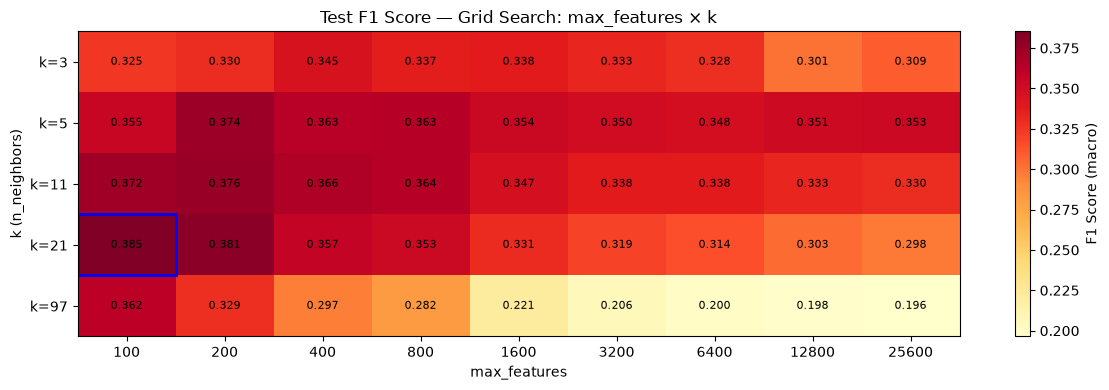

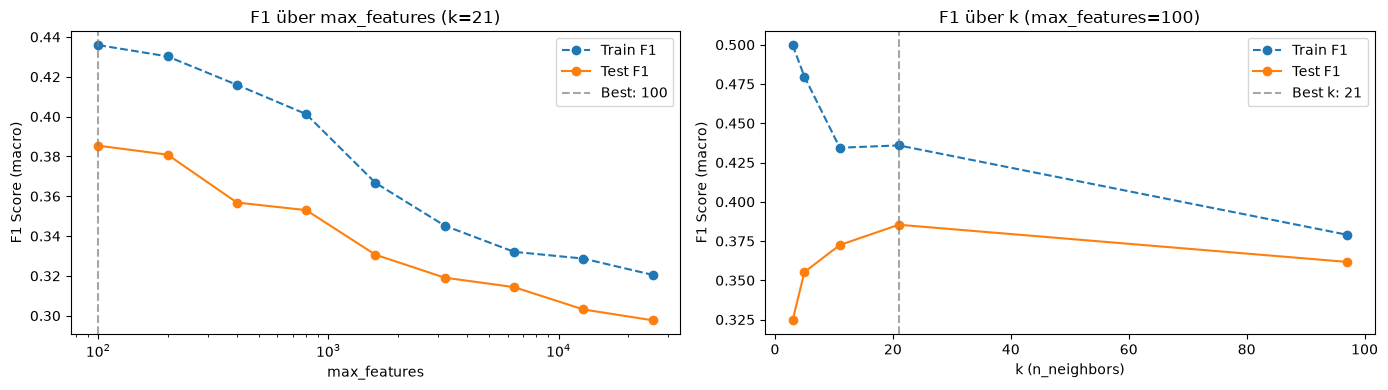

In [ ]:
# Heatmap
fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(test_matrix, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(feature_counts)))
ax.set_xticklabels(feature_counts)
ax.set_yticks(range(len(k_values_grid)))
ax.set_yticklabels([f"k={k}" for k in k_values_grid])
ax.set_xlabel("max_features")
ax.set_ylabel("k (n_neighbors)")
ax.set_title("Test F1 Score — Grid Search: max_features × k")
for i in range(len(k_values_grid)):
    for j in range(len(feature_counts)):
        ax.text(j, i, f"{test_matrix[i, j]:.3f}", ha="center", va="center", fontsize=8)
ax.add_patch(plt.Rectangle(
    (best_idx[1] - 0.5, best_idx[0] - 0.5), 1, 1,
    fill=False, edgecolor="blue", linewidth=2
))
plt.colorbar(im, ax=ax, label="F1 Score (macro)")
plt.tight_layout()
plt.show()

# F1 over max_features (slice at best k) + F1 over k (slice at best max_features)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(feature_counts, train_matrix[best_idx[0]], linestyle="--", marker="o", color="tab:blue", label="Train F1")
axes[0].plot(feature_counts, test_matrix[best_idx[0]], linestyle="-", marker="o", color="tab:orange", label="Test F1")
axes[0].axvline(best_max_features, color="gray", linestyle="--", alpha=0.7, label=f"Best: {best_max_features}")
axes[0].set_xscale("log")
axes[0].set_xlabel("max_features")
axes[0].set_ylabel("F1 Score (macro)")
axes[0].set_title(f"F1 über max_features (k={best_k})")
axes[0].legend()

axes[1].plot(k_values_grid, train_matrix[:, best_idx[1]], linestyle="--", marker="o", color="tab:blue", label="Train F1")
axes[1].plot(k_values_grid, test_matrix[:, best_idx[1]], linestyle="-", marker="o", color="tab:orange", label="Test F1")
axes[1].axvline(best_k, color="gray", linestyle="--", alpha=0.7, label=f"Best k: {best_k}")
axes[1].set_xlabel("k (n_neighbors)")
axes[1].set_ylabel("F1 Score (macro)")
axes[1].set_title(f"F1 über k (max_features={best_max_features})")
axes[1].legend()

plt.tight_layout()
plt.show()